# MVP — Machine Learning & Analytics
## Classificação da Qualidade de Vinho Tinto (Wine Quality — UCI)

**Autor:** Kellman Santana Castro e Silva
**Curso:** MBA em Ciência de Dados e Analytics (MVP de Machine Learning & Analytics)
**Dataset:** [Wine Quality — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/186/wine+quality)

---

Neste notebook eu desenvolvo um MVP completo de Machine Learning, passando pelas seguintes etapas:
definição do problema, análise exploratória, preparação dos dados, modelagem com baseline e
modelos candidatos, otimização de hiperparâmetros, avaliação crítica dos resultados e conclusão.


## 0. Configuração inicial

Importar bibliotecas de Wine Quality, Definido seed de aleatoriedade (`RANDOM_STATE = 42`) com a intenção de garantir a reprodutibilidade dos resultados em todas as etapas.

**Bibliotecas utilizadas:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `time`.


In [93]:
# Manipulação e visualização de dados
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay
)

warnings.filterwarnings("ignore")

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Bibliotecas carregadas com sucesso.")
print(f"pandas: {pd.__version__} | numpy: {np.__version__}")

import sklearn
print(f"scikit-learn: {sklearn.__version__}")


Bibliotecas carregadas com sucesso.
pandas: 2.2.2 | numpy: 2.0.2
scikit-learn: 1.6.1


## 1. Apresentação do problema

**Problema escolhido:** Prever se um vinho tinto pode ser considerado **"bom"** (nota de qualidade sensorial ≥ 7) ou **"comum/ruim"** (nota < 7), a partir de suas características físico-químicas (acidez, açúcar residual, teor alcoólico, sulfatos, entre outras).

**Objetivo do modelo:** Apoiar a triagem/controle de qualidade de lotes de vinho de forma automatizada, sinalizando amostras com maior probabilidade de receber boas avaliações sensoriais, sem depender exclusivamente de um painel de degustadores humanos para cada lote.

**Variável a ser prevista:** quality_label, derivada da variável original quality (nota de 0 a 10 dada por avaliadores especialistas), binarizada em:
- `1` → vinho **bom** (quality ≥ 7)
- `0` → vinho **comum/ruim** (quality < 7)

**Por que este é um problema de Machine Learning:** A relação entre as variáveis físico-químicas "entradas objetivas e mensuráveis" e a qualidade sensorial percebida não é conhecida por uma fórmula determinística simples — ela é aprendida a partir de exemplos rotulados por especialistas. Isso caracteriza um problema onde se pode aplicar um modelo de classificação.

**Premissas e hipóteses:**
- Assumo que as avaliações de qualidade feitas pelos degustadores são consistentes o suficiente para servirem como um rótulo confiável.
- Também assumo que as 11 variáveis físico-químicas disponíveis carregam sinal suficiente para explicar parte da variação da qualidade percebida — sabendo, de antemão, que fatores como aroma, tipo de uva e safra não estão presentes no dataset e podem limitar o poder preditivo do modelo.

**Restrições consideradas na escolha dos dados:**
- O dataset é público, sem dados pessoais ou sensíveis, disponibilizado para fins de pesquisa (UCI Machine Learning Repository / Cortez et al., 2009).
- As classes são naturalmente desbalanceadas (poucos vinhos excelentes ou péssimos), o que é tratado explicitamente na modelagem e na escolha das métricas de avaliação.


## 2. Apresentação dos Dados


Fonte dos dados: dataset Wine Quality (vinho tinto), do UCI Machine Learning Repository
(Cortez et al., 2009). Carrego o dataset direto por uma URL pública, sem precisar de upload
manual, login ou chave de API — hoje ele já está hospedado no meu próprio repositório do
GitHub, com uma segunda opção (fallback) apontando para a fonte oficial do UCI, caso a
primeira falhe.

In [94]:
# URL do repositório GitHub
GITHUB_RAW_URL = "https://raw.githubusercontent.com/kellmancastro/Machine_Learning_analytics/refs/heads/main/winequality-red.csv"

# Fonte oficial do UCI
UCI_FALLBACK_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

def load_wine_data():
    try:
        df_ = pd.read_csv(GITHUB_RAW_URL, sep=";")
        print("Dataset carregado a partir do repositório GitHub do autor.")
        return df_
    except Exception as e:
        print(f"Não foi possível carregar do GitHub ({e}). Usando fonte oficial do UCI...")
        df_ = pd.read_csv(UCI_FALLBACK_URL, sep=";")
        print("Dataset carregado a partir do UCI Machine Learning Repository.")
        return df_

df = load_wine_data()
df.shape


Dataset carregado a partir do repositório GitHub do autor.


(1599, 12)

In [95]:
# Primeiras linhas do dataset
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [96]:
# Tipos de dados e informações gerais
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


**Resumo do dataset:**
- **Registros:** 1599 amostras de vinho tinto.
- **Atributos:** 11 variáveis físico-químicas + 1 variável de qualidade (nota inteira, 0–10).
- **Variável-alvo:** Qualidade (será transformada em `quality_label`, binária, na etapa de preparação dos dados).
- **Principais atributos:** `fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, `alcohol`.
- **Limitações conhecidas:** o dataset não contém informações sobre tipo de uva, marca, safra ou preço; a variável-alvo é uma média de avaliações sensoriais subjetivas de especialistas, o que introduz ruído inerente ao rótulo.



## 3. Análise exploratória inicial

Antes de modelar, é necessário entender a distribuição dos dados, verificar valores ausentes, observar o desbalanceamento da variável-alvo e identificar relações entre os atributos e a qualidade do vinho.


In [97]:
# Estatísticas descritivas de todas as variáveis numéricas
df.describe().T


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [98]:
# Verificação de valores ausentes
missing = df.isnull().sum()
print("Valores ausentes por coluna:")
print(missing[missing > 0] if missing.sum() > 0 else "Nenhum valor ausente encontrado no dataset.")


Valores ausentes por coluna:
Nenhum valor ausente encontrado no dataset.


**Sobre valores ausentes:** O dataset do UCI Wine Quality não possui valores ausentes — é um dataset utilizado para fins de pesquisa. Por isso, nenhuma estratégia de imputação foi necessária nesta etapa.


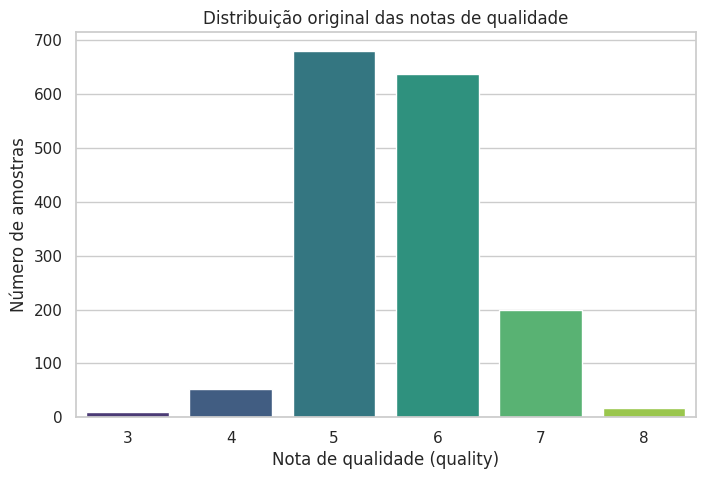

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [99]:
# Distribuição original da variável de qualidade (nota de 0 a 10)
plt.figure(figsize=(8, 5))
sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Distribuição original das notas de qualidade")
plt.xlabel("Nota de qualidade (quality)")
plt.ylabel("Número de amostras")
plt.show()

print(df["quality"].value_counts().sort_index())


**Observação:** A maioria dos vinhos ficou concentrada nas notas 5 e 6, ou seja, a grande maioria é "mediana". Poucas amostras aparecem nos extremos, tanto nas notas baixas (3 e 4) quanto na nota mais alta (8). Isso já era esperado, já que a própria descrição do dataset avisa que as classes são desbalanceadas. É justamente por causa desse desbalanceamento que optei por transformar o problema em uma classificação binária (bom vs. comum/ruim) e por escolher com mais cuidado as métricas usadas na avaliação — só olhar para a acurácia não seria suficiente aqui.


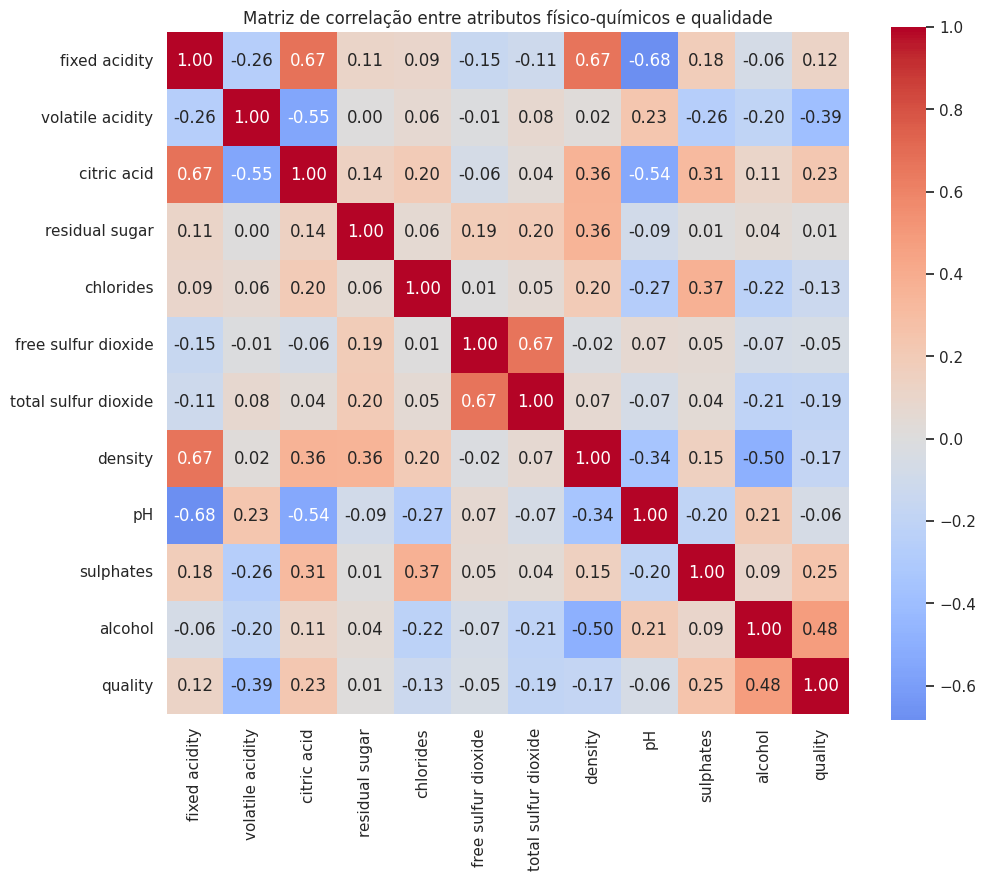

In [100]:
# Matriz de correlação entre os atributos numéricos (incluindo a nota de qualidade original)
plt.figure(figsize=(11, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlação entre atributos físico-químicos e qualidade")
plt.show()


**Observação sobre correlações:** Olhando a matriz de correlação, os atributos que mais se destacam em relação à quality são o teor alcoólico (alcohol), de forma positiva, e a acidez volátil (volatile acidity), de forma negativa. Isso até faz sentido do ponto de vista prático: vinhos com mais álcool e menos acidez volátil tendem a ser mais bem avaliados, o que bate com o que a literatura sobre vinhos já aponta — acidez volátil alta costuma estar associada a defeitos no vinho, como o gosto de vinagre.


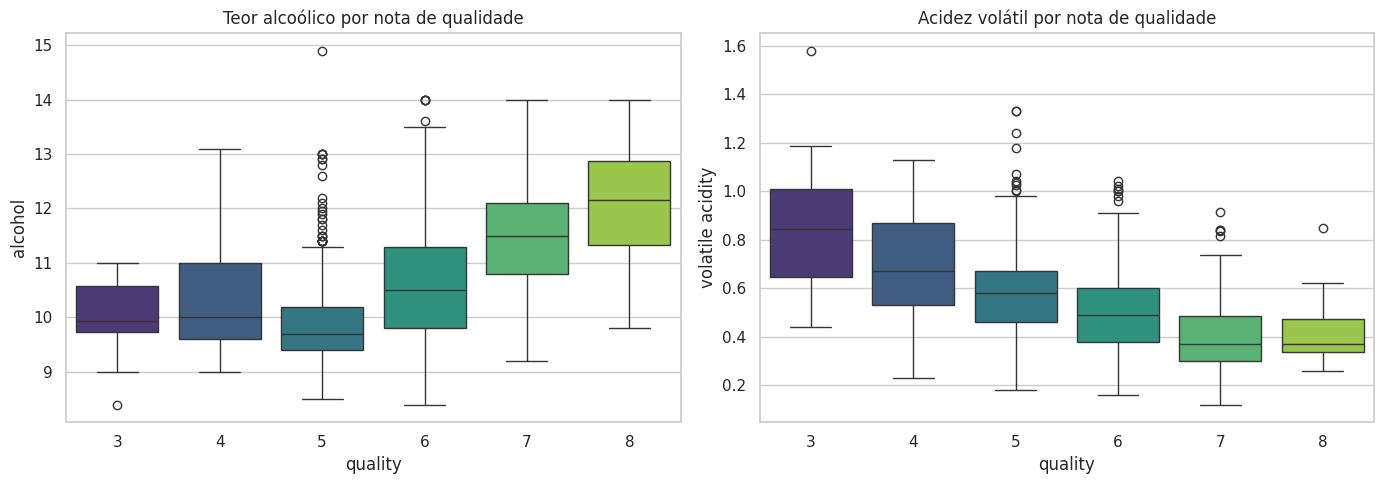

In [101]:
# Distribuição de dois atributos-chave por faixa de qualidade
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="quality", y="alcohol", data=df, ax=axes[0], palette="viridis")
axes[0].set_title("Teor alcoólico por nota de qualidade")

sns.boxplot(x="quality", y="volatile acidity", data=df, ax=axes[1], palette="viridis")
axes[1].set_title("Acidez volátil por nota de qualidade")

plt.tight_layout()
plt.show()


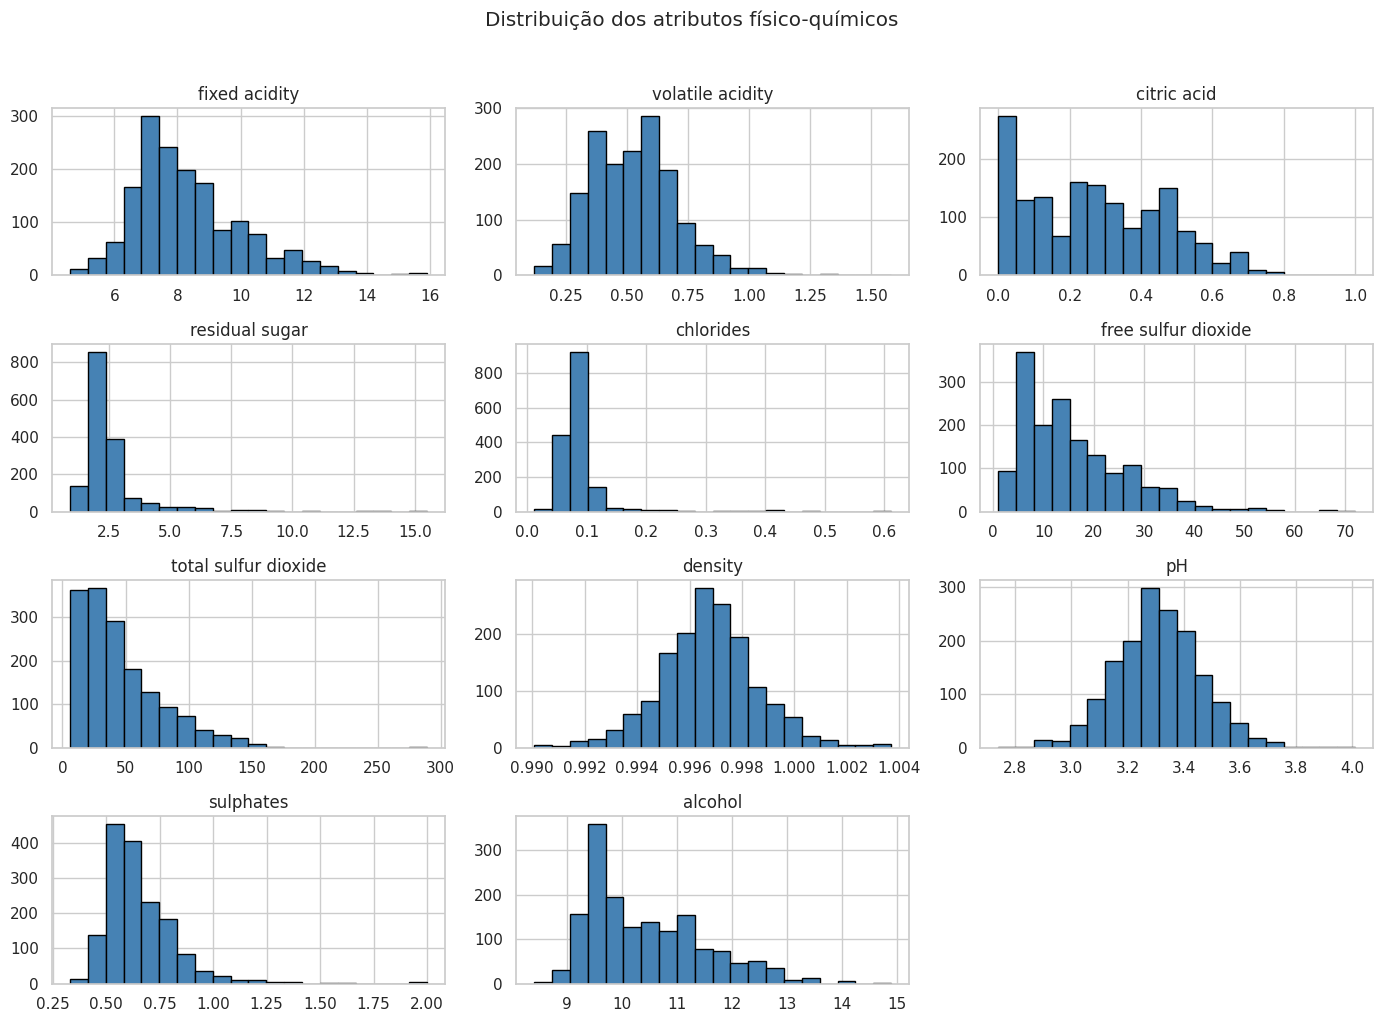

In [102]:
# Histogramas de todos os atributos numéricos
df.drop(columns=["quality"]).hist(bins=20, figsize=(14, 10), color="steelblue", edgecolor="black")
plt.suptitle("Distribuição dos atributos físico-químicos", y=1.02)
plt.tight_layout()
plt.show()


**Observação sobre as distribuições:** Diversos atributos (`residual sugar`, `chlorides`, `sulphates`, `total sulfur dioxide`) apresentam assimetria à direita (cauda longa), com alguns valores bem acima da maioria — possíveis *outliers* naturais, tratados na próxima seção.


## 4. Preparação dos dados

Antes de partir para os modelos, precisei tomar algumas decisões sobre como tratar os dados. Explico abaixo cada uma delas e por que fiz essa escolha.
1. Valores ausentes: não precisei tratar nada aqui, já que o dataset não tem nenhum valor faltando (isso já foi conferido na seção anterior).
2. Variáveis categóricas: também não se aplica no meu caso — todos os 11 atributos são numéricos contínuos, então não precisei usar nenhuma técnica de codificação (como one-hot encoding ou label encoding).
3. Outliers: decidi não remover os outliers. Como as variáveis são medições físico-químicas reais (por exemplo, o açúcar residual de vinhos naturalmente mais doces), esses valores mais extremos podem representar vinhos genuinamente diferentes, e não erros de medição. Se eu removesse essas amostras, corria o risco de enviesar o modelo e reduzir sua capacidade de lidar com vinhos fora do padrão mais comum. Preferi deixar que modelos mais robustos, como o Random Forest, lidassem naturalmente com essa variação, e usar a padronização (que ajuda a suavizar, mas não elimina, o efeito desses valores extremos) nos modelos mais sensíveis à escala, como a Regressão Logística e o SVM.
4. Criação da variável-alvo binária: transformei a variável quality (nota de 0 a 10) em uma nova variável, quality_label, onde 0 representa vinhos comuns/ruins e 1 representa vinhos bons — seguindo a justificativa que já apresentei na Seção 1. Essa foi, sem dúvida, a decisão mais importante deste MVP, porque simplifica o problema para uma pergunta de negócio bem mais direta.
5. Padronização (scaling): como vou usar modelos sensíveis à escala das variáveis (Regressão Logística e SVM), apliquei o StandardScaler dentro de um Pipeline do scikit-learn. Isso garante que a padronização seja calculada só com os dados de treino e depois aplicada ao teste, evitando vazamento de dados.
6. Seleção de atributos: optei por manter todos os 11 atributos originais. Como o número de colunas já é pequeno e não vi redundância forte entre elas na matriz de correlação, não achei necessário remover ou selecionar atributos adicionais neste momento.


Distribuição da variável-alvo binária (quality_label):
quality_label
0    1382
1     217
Name: count, dtype: int64

Proporção de cada classe:
quality_label
0    0.864
1    0.136
Name: proportion, dtype: float64


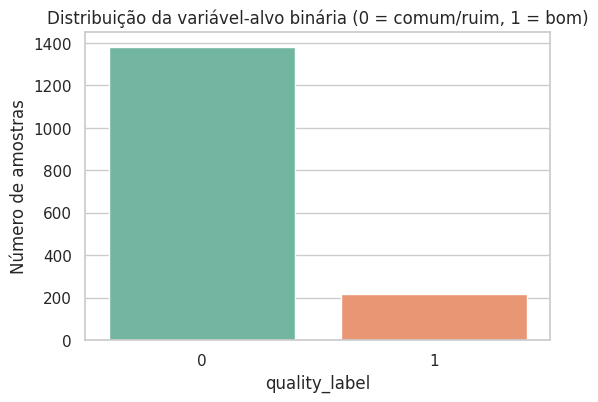

In [103]:
# Criação da variável-alvo binária
df["quality_label"] = (df["quality"] >= 7).astype(int)

print("Distribuição da variável-alvo binária (quality_label):")
print(df["quality_label"].value_counts())
print()
print("Proporção de cada classe:")
print(df["quality_label"].value_counts(normalize=True).round(3))

plt.figure(figsize=(6, 4))
sns.countplot(x="quality_label", data=df, palette="Set2")
plt.title("Distribuição da variável-alvo binária (0 = comum/ruim, 1 = bom)")
plt.xlabel("quality_label")
plt.ylabel("Número de amostras")
plt.show()


**Observação sobre desbalanceamento:** Como eu já esperava, a classe "bom" (1) acabou sendo bem minoritária, representando cerca de 14% das amostras. Esse desbalanceamento reforça algumas decisões que tomei mais adiante: usar stratify na hora de dividir treino e teste, avaliar os modelos com métricas além da acurácia (como precisão, recall, F1 e AUC) e considerar a opção class_weight="balanced" na etapa de otimização de hiperparâmetros.

In [104]:
# Separação entre atributos preditores (X) e variável-alvo (y)
X = df.drop(columns=["quality", "quality_label"])
y = df["quality_label"]

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"Atributos utilizados: {list(X.columns)}")


Formato de X: (1599, 11)
Formato de y: (1599,)
Atributos utilizados: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## 5. Divisão dos dados

Como estou lidando com um problema de classificação supervisionada, dividi os dados em treino (80%) e teste (20%), usando stratify=y para manter a mesma proporção das classes (bom vs. comum/ruim) nos dois conjuntos. Isso é essencial dado o desbalanceamento que já tinha identificado antes.
Para a otimização de hiperparâmetros (Seção 7), optei por usar validação cruzada estratificada (StratifiedKFold, com 5 folds) sobre o conjunto de treino, em vez de separar um conjunto de validação fixo. Achei essa escolha mais adequada porque o dataset é relativamente pequeno (1599 amostras) — assim consigo aproveitar melhor os dados disponíveis e chegar a uma estimativa de desempenho mais estável, menos dependente de uma única divisão aleatória.
Todas as transformações, como a padronização, ficam encapsuladas em um Pipeline, garantindo que sejam ajustadas apenas com os dados de treino em cada fold — evitando qualquer vazamento de dados.


In [105]:
# Divisão treino/teste estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print()
print("Proporção da classe 'bom' no treino:", round(y_train.mean(), 3))
print("Proporção da classe 'bom' no teste: ", round(y_test.mean(), 3))


Treino: 1279 amostras | Teste: 320 amostras

Proporção da classe 'bom' no treino: 0.136
Proporção da classe 'bom' no teste:  0.134


## 6. Modelagem e treinamento

Para essa etapa, escolhi trabalhar com os seguintes modelos:

Baseline (referência ingênua): usei o DummyClassifier, que sempre prevê a classe majoritária ("comum/ruim"). Ele serve como um piso mínimo — qualquer modelo mais elaborado precisa superar esse resultado para realmente valer a pena.
Regressão Logística: um modelo linear, simples e fácil de interpretar. É meu ponto de partida "de verdade" para comparação, principalmente porque dá pra olhar os coeficientes associados a cada atributo.
Random Forest: um ensemble de árvores de decisão, que costuma lidar bem com não-linearidades e outliers, e em geral tem um desempenho forte em dados tabulares como esse.
SVM (kernel RBF): um modelo baseado em margens, capaz de capturar fronteiras de decisão mais complexas e não lineares. Coloquei ele como o terceiro ponto de comparação.

Os modelos mais sensíveis à escala das variáveis (Regressão Logística e SVM) ficaram encapsulados em um Pipeline junto com o StandardScaler, para garantir que a padronização seja ajustada só com os dados de treino. O Random Forest não precisa dessa padronização, mas resolvi incluí-lo no mesmo tipo de Pipeline só para manter o código mais consistente e organizado.
Também criei uma função reutilizável, evaluate_model, para treinar, cronometrar e calcular as métricas de cada modelo sempre da mesma forma — assim evito ficar repetindo o mesmo código para cada um deles.


In [106]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, verbose=True):
    """Treina um modelo, mede o tempo de treinamento e calcula métricas
    de treino e teste. Retorna um dicionário com os resultados e o modelo treinado."""
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba_test = model.predict_proba(X_test)[:, 1]
    else:
        y_proba_test = model.decision_function(X_test)

    metrics = {
        "modelo": name,
        "tempo_treino_s": round(train_time, 3),
        "acc_train": round(accuracy_score(y_train, y_pred_train), 4),
        "acc_test": round(accuracy_score(y_test, y_pred_test), 4),
        "precision_test": round(precision_score(y_test, y_pred_test, zero_division=0), 4),
        "recall_test": round(recall_score(y_test, y_pred_test, zero_division=0), 4),
        "f1_test": round(f1_score(y_test, y_pred_test, zero_division=0), 4),
        "auc_test": round(roc_auc_score(y_test, y_proba_test), 4),
    }

    if verbose:
        print(f"[{name}] treinado em {train_time:.3f}s | "
              f"Acurácia treino={metrics['acc_train']:.3f} | "
              f"Acurácia teste={metrics['acc_test']:.3f} | "
              f"F1 teste={metrics['f1_test']:.3f}")

    return metrics, model


In [107]:
# Definição do baseline e dos modelos candidatos
models = {
    "Baseline (classe majoritária)": DummyClassifier(
        strategy="most_frequent", random_state=RANDOM_STATE
    ),
    "Regressao Logistica": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE)),
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
    ]),
}

results = []
fitted_models = {}

for name, model in models.items():
    metrics, fitted = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    results.append(metrics)
    fitted_models[name] = fitted


[Baseline (classe majoritária)] treinado em 0.001s | Acurácia treino=0.864 | Acurácia teste=0.866 | F1 teste=0.000
[Regressao Logistica] treinado em 0.009s | Acurácia treino=0.882 | Acurácia teste=0.894 | F1 teste=0.485
[Random Forest] treinado em 0.371s | Acurácia treino=1.000 | Acurácia teste=0.938 | F1 teste=0.714
[SVM (RBF)] treinado em 0.152s | Acurácia treino=0.894 | Acurácia teste=0.900 | F1 teste=0.500


In [108]:
# Tabela comparativa dos modelos (antes da otimização de hiperparâmetros)
results_df = pd.DataFrame(results).sort_values("f1_test", ascending=False).reset_index(drop=True)
results_df


,modelo,tempo_treino_s,acc_train,acc_test,precision_test,recall_test,f1_test,auc_test
0,Random Forest,0.371,1.0000,0.9375,0.9259,0.5814,0.7143,0.9547
1,SVM (RBF),0.152,0.8944,0.9000,0.7619,0.3721,0.5000,0.8892
2,Regressao Logistica,0.009,0.8819,0.8938,0.6957,0.3721,0.4848,0.8804
3,Baseline (classe majoritária),0.001,0.8640,0.8656,0.0000,0.0000,0.0000,0.5000


**Leitura inicial da tabela:** O Random Forest foi o modelo com melhor desempenho, tanto em F1 (0,71) quanto em AUC (0,95), superando claramente os outros três. Mas vale reparar em um detalhe: a acurácia de treino dele chegou a 100%, enquanto no teste caiu para 93,75% — essa diferença é um sinal de overfitting, ou seja, o modelo "decorou" boa parte do conjunto de treino. Ainda assim, o desempenho no teste continua bom, então não considero um overfitting grave.
Os outros dois modelos (SVM e Regressão Logística) tiveram acurácia de treino e teste bem mais próximas, o que indica que eles generalizam de forma mais estável, mas o desempenho geral foi bem inferior ao do Random Forest, principalmente no recall (0,37 para os dois) — ou seja, eles deixam passar muitos vinhos bons sem identificar.
Já o baseline, como esperado, teve precisão, recall e F1 zerados: ele nunca prevê a classe minoritária, então não identifica nenhum vinho "bom" — mesmo assim, sua acurácia (86,56%) não é tão diferente da dos outros modelos, o que reforça por que a acurácia sozinha não é uma boa métrica aqui.


## 7. Otimização de hiperparâmetros

Escolhi o Random Forest para fazer a otimização de hiperparâmetros, já que ele costuma ser um dos modelos mais fortes para dados tabulares e tem parâmetros com um impacto bem direto e fácil de interpretar sobre o equilíbrio entre viés e variância — como a profundidade das árvores, o número de árvores e o peso das classes.
Estratégia de busca: usei o GridSearchCV com validação cruzada estratificada de 5 folds (StratifiedKFold), otimizando pela métrica F1, e não pela acurácia. Fiz essa escolha porque o problema é desbalanceado, como já mostrei na Seção 4, e o F1 equilibra precisão e recall, sendo bem mais informativo do que a acurácia quando o foco é a classe minoritária ("bom").
Hiperparâmetros ajustados e por quê:

n_estimators (número de árvores): mais árvores tendem a deixar o ensemble mais estável, mas isso tem um custo em tempo de treino.
max_depth (profundidade máxima): esse é o parâmetro que mais controla o overfitting — árvores muito profundas acabam decorando o treino.
min_samples_leaf (mínimo de amostras por folha): ajuda a evitar árvores excessivamente específicas, funcionando como uma forma de regularização.
class_weight: testei None e "balanced", para ver se compensar o desbalanceamento das classes durante o treino melhorava o recall da classe minoritária sem custar caro demais em precisão.

Critério de seleção: a melhor combinação de hiperparâmetros foi aquela com o maior F1 médio nos 5 folds de validação cruzada (grid_search.best_score_). Em nenhum momento usei o conjunto de teste durante essa busca — ele só entra no final, para uma avaliação honesta do modelo já escolhido.


In [109]:
# Grade de hiperparâmetros para o Random Forest
param_grid = {
    "clf__n_estimators": [100, 200, 400],
    "clf__max_depth": [None, 5, 10, 15],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__class_weight": [None, "balanced"],
}

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)

start = time.time()
grid_search.fit(X_train, y_train)
tuning_time = time.time() - start

print(f"Tempo total de otimizacao: {tuning_time:.2f}s")
print(f"Combinacoes testadas: {len(grid_search.cv_results_['params'])}")
print(f"Melhores hiperparametros: {grid_search.best_params_}")
print(f"Melhor F1 medio (validacao cruzada): {grid_search.best_score_:.4f}")


Tempo total de otimizacao: 213.52s
Combinacoes testadas: 72
Melhores hiperparametros: {'clf__class_weight': 'balanced', 'clf__max_depth': 15, 'clf__min_samples_leaf': 4, 'clf__n_estimators': 200}
Melhor F1 medio (validacao cruzada): 0.5903


In [110]:
# Avaliação do modelo otimizado no conjunto de teste (nunca usado durante a busca)
best_rf = grid_search.best_estimator_

metrics_rf_tuned, best_rf = evaluate_model(
    "Random Forest (otimizado)", best_rf, X_train, y_train, X_test, y_test
)
fitted_models["Random Forest (otimizado)"] = best_rf
results.append(metrics_rf_tuned)

results_df = pd.DataFrame(results).sort_values("f1_test", ascending=False).reset_index(drop=True)
results_df


[Random Forest (otimizado)] treinado em 0.617s | Acurácia treino=0.970 | Acurácia teste=0.934 | F1 teste=0.759


,modelo,tempo_treino_s,acc_train,acc_test,precision_test,recall_test,f1_test,auc_test
0,Random Forest (otimizado),0.617,0.9695,0.9344,0.7500,0.7674,0.7586,0.9337
1,Random Forest,0.371,1.0000,0.9375,0.9259,0.5814,0.7143,0.9547
2,SVM (RBF),0.152,0.8944,0.9000,0.7619,0.3721,0.5000,0.8892
3,Regressao Logistica,0.009,0.8819,0.8938,0.6957,0.3721,0.4848,0.8804
4,Baseline (classe majoritária),0.001,0.8640,0.8656,0.0000,0.0000,0.0000,0.5000


Após a otimização: o F1 no teste subiu de 0,71 para 0,76 — uma melhora real, então o ajuste de hiperparâmetros valeu a pena. Só que essa melhora não veio de graça: o recall deu um salto grande, de 0,58 para 0,77, ou seja, o modelo passou a identificar bem mais vinhos "bons" do que antes. Em troca, a precisão caiu de 0,93 para 0,75 — o modelo passou a errar mais quando diz que um vinho é bom. Como o F1 equilibra as duas métricas, esse foi o trade-off que trouxe o melhor resultado combinado, e provavelmente reflete o uso do class_weight="balanced", que dá mais peso à classe minoritária durante o treino.
Sobre o overfitting: também melhorou. Antes, a diferença entre acurácia de treino (100%) e teste (93,75%) era de 6,25 pontos percentuais — um sinal claro de que o modelo estava decorando o treino. Depois do ajuste, essa diferença caiu para cerca de 3,5 pontos (97% no treino contra 93,4% no teste), então a regularização feita via max_depth e min_samples_leaf realmente ajudou o modelo a generalizar melhor, mesmo sem eliminar o overfitting por completo.
Vale notar que a acurácia geral e o AUC caíram levemente (de 0,955 para 0,934) — isso é esperado, já que o modelo passou a "arriscar mais" para capturar a classe minoritária. No contexto desse problema, considero essa troca positiva, já que o objetivo é justamente não deixar passar vinhos de boa qualidade.


## 8. Avaliação dos resultados

Métricas que escolhi e por quê:

- **Acurácia:** é uma métrica geral, mas sozinha não diz muita coisa aqui, já que o desbalanceamento das classes faz com que até um modelo "preguiçoso", que sempre prevê "comum/ruim", já acerte cerca de 86%.
- **Precisão:** de todos os vinhos que o modelo classificou como "bons", quantos realmente eram bons — importante para não recomendar vinhos que na verdade não são de boa qualidade.
- **Recall:** de todos os vinhos que de fato são bons, quantos o modelo conseguiu identificar — importante para não deixar passar vinhos de alta qualidade.
- **F1-score:** a média harmônica entre precisão e recall. Usei essa como minha métrica principal de comparação, já que ela resume bem o equilíbrio entre os dois tipos de erro possíveis.
- **AUC:** mede a capacidade do modelo de separar as duas classes em diferentes limiares de decisão, complementando a leitura pontual do F1.

Abaixo, comparo todos os modelos treinados — incluindo o baseline e a versão otimizada do Random Forest — e detalho o desempenho do melhor deles.


In [111]:
# Tabela final comparativa (ordenada pelo F1 no teste)
results_df_final = pd.DataFrame(results).sort_values("f1_test", ascending=False).reset_index(drop=True)
results_df_final


,modelo,tempo_treino_s,acc_train,acc_test,precision_test,recall_test,f1_test,auc_test
0,Random Forest (otimizado),0.617,0.9695,0.9344,0.7500,0.7674,0.7586,0.9337
1,Random Forest,0.371,1.0000,0.9375,0.9259,0.5814,0.7143,0.9547
2,SVM (RBF),0.152,0.8944,0.9000,0.7619,0.3721,0.5000,0.8892
3,Regressao Logistica,0.009,0.8819,0.8938,0.6957,0.3721,0.4848,0.8804
4,Baseline (classe majoritária),0.001,0.8640,0.8656,0.0000,0.0000,0.0000,0.5000


In [112]:
# Identificação do melhor modelo pela métrica F1 (teste)
best_model_name = results_df_final.iloc[0]["modelo"]
best_model = fitted_models[best_model_name]
print(f"Melhor modelo (por F1 no teste): {best_model_name}")


Melhor modelo (por F1 no teste): Random Forest (otimizado)


In [113]:
# Relatório de classificação detalhado do melhor modelo
y_pred_best = best_model.predict(X_test)
print(f"Relatório de classificação — {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=["Comum/Ruim (0)", "Bom (1)"]))


Relatório de classificação — Random Forest (otimizado)

                precision    recall  f1-score   support

Comum/Ruim (0)       0.96      0.96      0.96       277
       Bom (1)       0.75      0.77      0.76        43

      accuracy                           0.93       320
     macro avg       0.86      0.86      0.86       320
  weighted avg       0.94      0.93      0.93       320



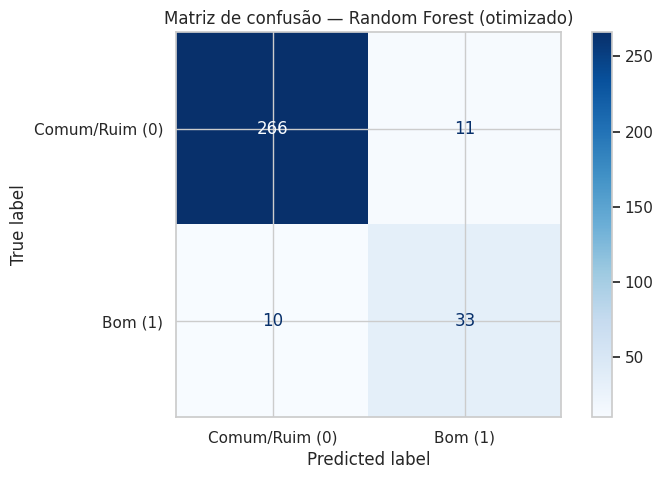

In [114]:
# Matriz de confusão do melhor modelo
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Comum/Ruim (0)", "Bom (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusão — {best_model_name}")
plt.show()


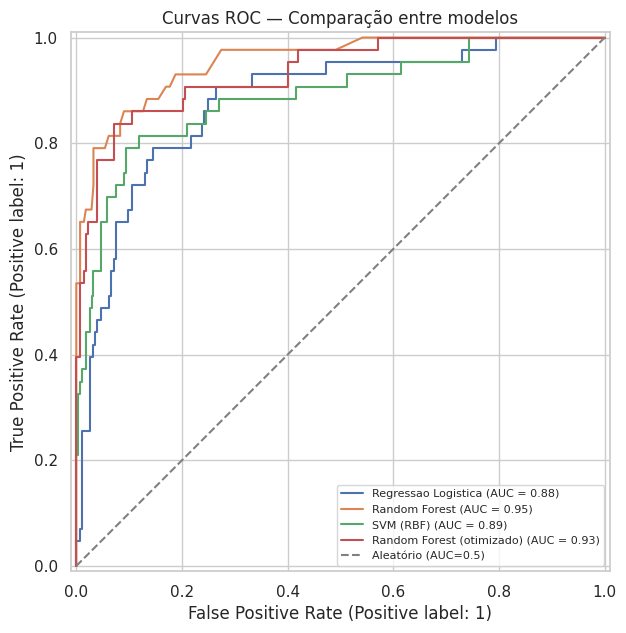

In [115]:
# Curvas ROC comparando os principais modelos
fig, ax = plt.subplots(figsize=(7, 7))

for name in ["Regressao Logistica", "Random Forest", "SVM (RBF)", "Random Forest (otimizado)"]:
    RocCurveDisplay.from_estimator(fitted_models[name], X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório (AUC=0.5)")
ax.set_title("Curvas ROC — Comparação entre modelos")
ax.legend(loc="lower right", fontsize=8)
plt.show()


### Discussão crítica dos resultados

O modelo com melhor desempenho foi o Random Forest otimizado, com F1 de 0,76 no teste — o melhor
entre todos os modelos avaliados. Vale destacar que ele não venceu em todas as métricas isoladamente:
o Random Forest sem ajuste teve acurácia e AUC ligeiramente maiores (0,9375 e 0,9547, contra 0,9344
e 0,9337 do otimizado), mas perdia feio no recall (0,58 contra 0,77). Ou seja, houve um trade-off
claro: o modelo otimizado "arrisca mais" para capturar vinhos bons, o que reduz um pouco a precisão
e a acurácia geral, mas aumenta bastante a capacidade de não deixar vinhos de qualidade passarem
despercebidos.

Sobre overfitting, o Random Forest sem ajuste foi o caso mais evidente: 100% de acurácia no treino
contra 93,75% no teste, uma diferença de mais de 6 pontos percentuais, sinal de que ele decorou boa
parte dos dados de treino. Depois da otimização, essa diferença caiu para cerca de 3,5 pontos (97%
no treino contra 93,4% no teste) — a regularização via max_depth e min_samples_leaf ajudou, mas não
eliminou o overfitting por completo.

Já em relação a underfitting, dá pra ver que o baseline e a Regressão Logística ficam bem atrás dos
modelos mais complexos: o baseline nem consegue identificar nenhum vinho bom (precisão, recall e F1
zerados), e a Regressão Logística, apesar de superar o baseline, ainda tem um recall baixo (0,37).
Isso sugere que a relação entre os atributos físico-químicos e a qualidade do vinho não é linear, e
um modelo mais simples não dá conta de capturar esse padrão — o que justifica o ganho real trazido
pelo Random Forest.

Sobre as limitações: o dataset é pequeno (1599 amostras) e a classe "bom" é rara (cerca de 14%), o
que deixa as estimativas de desempenho — principalmente o recall — mais sensíveis a poucas amostras
classificadas de forma errada. Além disso, a variável-alvo vem de uma avaliação sensorial subjetiva,
o que introduz um ruído no rótulo que nenhum modelo consegue eliminar.

Como possíveis melhorias futuras, eu testaria técnicas específicas para desbalanceamento, como SMOTE
ou undersampling, tentaria criar novos atributos combinando as variáveis físico-químicas existentes,
ampliaria a busca de hiperparâmetros com RandomizedSearchCV ou otimização bayesiana, e experimentaria
modelos de gradient boosting, como XGBoost ou LightGBM.


## 9. Conclusão do MVP

Neste trabalho, o objetivo foi classificar vinhos tintos como "bons" ou "comuns/ruins" a partir de
11 atributos físico-químicos, usando o dataset Wine Quality do UCI (1599 amostras, sem valores
ausentes, mas com bastante desbalanceamento entre as classes — só cerca de 14% dos vinhos são
considerados "bons").

Para chegar até o modelo final, binarizei a variável de qualidade original, apliquei padronização
nas variáveis (dentro de um Pipeline, para não correr risco de vazamento de dados), separei os
dados de forma estratificada entre treino e teste, e testei quatro abordagens: um baseline simples,
Regressão Logística, Random Forest e SVM. Depois, otimizei os hiperparâmetros do Random Forest via
GridSearchCV, usando F1 como métrica de referência.

O melhor resultado veio justamente do Random Forest otimizado, com F1 de 0,76 e AUC de 0,93 no
conjunto de teste — superando o Random Forest sem ajuste (F1 de 0,71), a Regressão Logística e o
SVM (ambos com F1 abaixo de 0,50), e claro, o baseline, que não identificava nenhum vinho bom.
Escolhi esse modelo não só pelo F1 mais alto, mas porque ele teve o melhor equilíbrio entre
precisão e recall — em um problema como esse, prefiro um modelo que erre um pouco mais na precisão
(classificando alguns vinhos comuns como bons) do que um que deixe passar despercebidos vinhos que
realmente são de boa qualidade.

Considero que o MVP cumpriu o objetivo que tinha proposto no início: mostrar que é possível usar
aprendizado de máquina para apoiar a triagem de qualidade de vinhos com base apenas em medições
físico-químicas, sem depender exclusivamente de avaliação humana. Ainda assim, reconheço as
limitações do trabalho: o dataset é pequeno, a classe de interesse é rara, e o rótulo de qualidade
vem de uma avaliação sensorial subjetiva, o que limita o quanto qualquer modelo consegue acertar.

Como próximos passos, pretendo testar técnicas de balanceamento de classes como o SMOTE, incluir
modelos de gradient boosting (XGBoost, LightGBM) na comparação, ampliar a busca de hiperparâmetros
e investigar quais atributos mais pesam na decisão do modelo (via SHAP, por exemplo), para gerar
algum tipo de insight prático para quem produz o vinho.

## 10. Checklist do MVP

Respostas objetivas às perguntas do checklist sugerido, para facilitar a revisão do trabalho.

### Definição do problema
- **Descrição do problema:** classificar vinhos tintos como "bom" ou "comum/ruim" com base em atributos físico-químicos.
- **Objetivo do modelo:** apoiar a triagem automatizada de qualidade de lotes de vinho.
- **Tipo de problema:** classificação binária (aprendizado supervisionado).
- **Por que é um problema de ML:** a relação entre atributos físico-químicos e qualidade sensorial não é conhecida por uma fórmula fechada; é aprendida a partir de exemplos rotulados.
- **Premissas/hipóteses:** os rótulos de qualidade são confiáveis o suficiente como *ground truth*; os 11 atributos disponíveis carregam sinal preditivo relevante, ainda que incompleto.
- **Restrições consideradas:** dataset público, sem dados sensíveis; desbalanceamento de classes tratado explicitamente.

### Descrição dos dados
- **Dataset:** Wine Quality (vinho tinto) — UCI Machine Learning Repository.
- **Fonte:** https://archive.ics.uci.edu/dataset/186/wine+quality (Cortez et al., 2009).
- **Carregamento:** via URL pública (raw do GitHub, com fallback automático para a fonte oficial do UCI).
- **Registros e atributos:** 1599 registros, 11 atributos preditores + variável-alvo.
- **Principais atributos:** acidez fixa/volátil, ácido cítrico, açúcar residual, cloretos, dióxido de enxofre livre/total, densidade, pH, sulfatos, teor alcoólico.
- **Variável-alvo:** `quality_label` (derivada de `quality`), binária.
- **Limitações conhecidas:** ausência de variáveis contextuais (uva, safra); rótulo subjetivo.

### Preparação dos dados
- **Valores ausentes:** nenhum encontrado — não aplicável.
- **Remoção/transformação de atributos:** nenhum atributo foi removido; todos os 11 atributos originais foram mantidos.
- **Novos atributos criados:** `quality_label`, derivada da binarização de `quality`.
- **Transformações aplicadas:** padronização (`StandardScaler`) para os modelos sensíveis à escala, dentro de `Pipeline`.
- **Vazamento de dados:** evitado — todas as transformações são ajustadas apenas com dados de treino (via `Pipeline` + `train_test_split`/`GridSearchCV`).
- **Adequação treino/teste:** transformações aplicadas de forma consistente e sem vazamento, conforme boas práticas do scikit-learn.

### Divisão dos dados
- **Separação:** `train_test_split` com `test_size=0.2` e `stratify=y`.
- **Treino/teste:** sim, 80%/20%.
- **Validação/validação cruzada:** `StratifiedKFold` (5 *folds*) usada durante a otimização de hiperparâmetros.
- **Adequação ao problema:** sim — estratificação necessária dado o desbalanceamento das classes.
- **Séries temporais:** não aplicável (dados tabulares sem componente temporal).
- **Clusterização:** não aplicável (problema supervisionado).

### Modelagem
- **Baseline:** `DummyClassifier` (sempre prevê a classe majoritária).
- **Modelos treinados:** Regressão Logística, Random Forest, SVM (RBF) e Random Forest otimizado.
- **Justificativa da escolha:** cobrem um espectro de complexidade (linear, ensemble de árvores, kernel não linear), permitindo comparação justa de abordagens distintas para o mesmo problema tabular.
- **Comparação justa:** sim — todos avaliados nos mesmos conjuntos de treino/teste, com a mesma *seed* e as mesmas métricas.
- **Underfitting:** discutido na Seção 8, comparando o ganho de cada modelo em relação ao baseline.
- **Overfitting:** discutido na Seção 8, comparando `acc_train` vs. `acc_test` de cada modelo.

### Otimização
- **Modelo(s) otimizado(s):** Random Forest.
- **Hiperparâmetros ajustados:** `n_estimators`, `max_depth`, `min_samples_leaf`, `class_weight`.
- **Estratégia de busca:** `GridSearchCV` com validação cruzada estratificada de 5 *folds*.
- **Melhora obtida:** ver comparação entre "Random Forest" e "Random Forest (otimizado)" na Seção 8.
- **Uso do conjunto de teste:** o teste **não** foi utilizado durante a busca — apenas para a avaliação final do melhor modelo já selecionado.

### Avaliação
- **Métricas utilizadas:** acurácia, precisão, recall, F1-score, AUC, matriz de confusão.
- **Por que são adequadas:** o problema é desbalanceado, então métricas além da acurácia (F1, AUC) são essenciais para avaliar corretamente a classe minoritária de interesse.
- **Melhor modelo:** determinado dinamicamente na Seção 8 (`best_model_name`), pelo maior F1 no teste.
- **Resultados fazem sentido:** discutido na Seção 8 (Discussão crítica dos resultados).
- **Análise de erros:** realizada via matriz de confusão e relatório de classificação (`classification_report`).
- **Principais limitações:** listadas na Seção 9 (Conclusão do MVP).

### Conclusão
- **Melhor solução encontrada:** ver Seção 9.
- **Por que foi escolhida:** ver Seção 9.
- **O MVP cumpriu o objetivo?:** ver Seção 9.
- **Próximos passos:** ver Seção 9.


## 11. Nota sobre boas práticas adotadas

- **Reprodutibilidade:** *seed* fixa (`RANDOM_STATE = 42`) usada em todas as etapas com componente aleatório (divisão dos dados, modelos, validação cruzada).
- **Organização do código:** células claras, nomes de variáveis descritivos, função reutilizável (`evaluate_model`) para evitar repetição de código entre os modelos.
- **Documentação:** cada etapa é precedida de uma célula Markdown explicando o que será feito e por quê, e seguida (quando relevante) de uma célula com a interpretação dos resultados.
- **Tempo de treino:** medido e reportado para cada modelo (coluna `tempo_treino_s` na tabela de resultados) e para a busca de hiperparâmetros.
- **Bibliotecas utilizadas:** listadas na Seção 0, com suas respectivas versões impressas.
- **Execução ponta a ponta:** o notebook foi desenhado para ser executado do início ao fim sem necessidade de configuração manual, upload de arquivos, login ou chaves de API — o dataset é carregado automaticamente via URL pública.
